# Task 1: Exploratory Data Analysis

This notebook documents the interim EDA evidence required by the rubric: data summaries, missing value strategy, univariate and bivariate analysis, geographic trends, outlier checks, guiding questions, and insight visualizations.

In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sys.path.append(str(Path.cwd().parent / "src"))
from data_loader import load_insurance_data, add_loss_ratio

sns.set_theme(style="whitegrid", palette="Set2")
df = add_loss_ratio(load_insurance_data(Path.cwd().parent / "data" / "raw" / "insurance_data.csv"))
df.head()

,PolicyID,TransactionMonth,Province,ZipCode,Gender,CoverType,VehicleType,make,Model,TotalPremium,...,smoker,risk_score,risk_category,claims_filed_1y,total_claims_amount,health_conditions,employment_status,income_bracket,policy_duration_years,LossRatio
0,POL0000001,2024-02-14,Western Cape,1863,Female,Third Party,Bakkie,BMW,320i,2106.60,...,0,10.00,High,0,0.00,3,Retired,>$100k,13,0.000000
1,POL0000002,2024-08-15,North West,4055,Female,Comprehensive,Bakkie,Toyota,Hilux,2443.31,...,0,9.66,High,0,0.00,4,Employed,$30k-$60k,12,0.000000
2,POL0000003,2023-03-09,Free State,6133,Female,Comprehensive,Hatchback,Toyota,Fortuner,2041.02,...,0,10.00,High,1,3106.97,0,Retired,$60k-$100k,13,1.522263
3,POL0000004,2024-12-19,Eastern Cape,3682,Male,Comprehensive,Sedan,Toyota,Fortuner,1087.96,...,0,6.62,High,0,0.00,0,Retired,>$100k,3,0.000000
4,POL0000005,2023-04-29,Gauteng,6278,Male,Comprehensive,Bakkie,Hyundai,Creta,2594.12,...,0,7.45,High,2,997.47,0,Self-employed,>$100k,2,0.384512


## Data Summarization and Missing Value Strategy

Descriptive statistics include `TotalPremium`, `TotalClaims`, `CustomValueEstimate`, and numerical risk features. Missing numeric values would be median-imputed due to skewed claim and premium distributions; missing categorical values would be labeled `Unknown` to preserve group counts.

In [2]:
display(df.dtypes.to_frame("dtype"))
summary_cols = ["TotalPremium", "TotalClaims", "CustomValueEstimate", "age", "coverage_amount", "risk_score", "LossRatio"]
display(df[summary_cols].describe().T)
missing = pd.DataFrame({"missing_count": df.isna().sum(), "missing_pct": (df.isna().mean() * 100).round(2)})
display(missing.sort_values("missing_count", ascending=False).head(12))

,dtype
PolicyID,str
TransactionMonth,datetime64[us]
Province,str
ZipCode,int64
Gender,str
CoverType,str
VehicleType,str
make,str
Model,str
TotalPremium,float64


,count,mean,std,min,25%,50%,75%,max
TotalPremium,10000.0,1.849934e+03,744.573602,443.83,1276.5900,1739.210,2.302677e+03,5.320260e+03
TotalClaims,10000.0,1.675413e+03,4039.695474,0.00,0.0000,0.000,1.737565e+03,1.076670e+05
CustomValueEstimate,10000.0,3.364663e+05,249085.205682,8847.62,138387.4325,273767.075,4.833400e+05,1.472470e+06
age,10000.0,4.908774e+01,17.766305,18.00,33.8000,49.100,6.460000e+01,8.000000e+01
coverage_amount,10000.0,1.039354e+06,549735.759678,100055.76,556820.0425,1038264.120,1.510480e+06,1.999985e+06
risk_score,10000.0,8.309958e+00,1.684177,2.01,7.0700,8.680,1.000000e+01,1.000000e+01
LossRatio,10000.0,1.030144e+00,2.563777,0.00,0.0000,0.000,9.619926e-01,6.102777e+01


,missing_count,missing_pct
PolicyID,0,0.0
TransactionMonth,0,0.0
Province,0,0.0
ZipCode,0,0.0
Gender,0,0.0
CoverType,0,0.0
VehicleType,0,0.0
make,0,0.0
Model,0,0.0
TotalPremium,0,0.0


## Visual Analysis

Univariate histograms and bivariate/multivariate analysis show the premium-claims relationship, including aggregation by `ZipCode` and a correlation matrix.

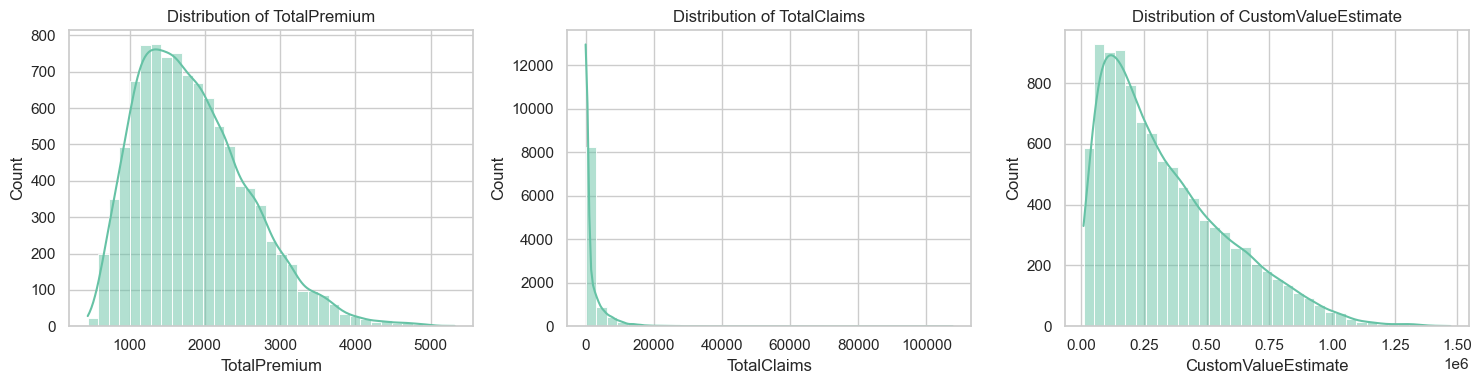

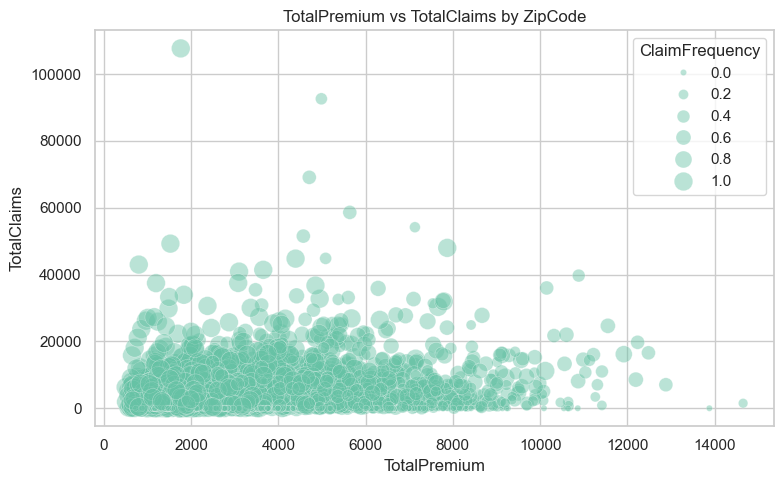

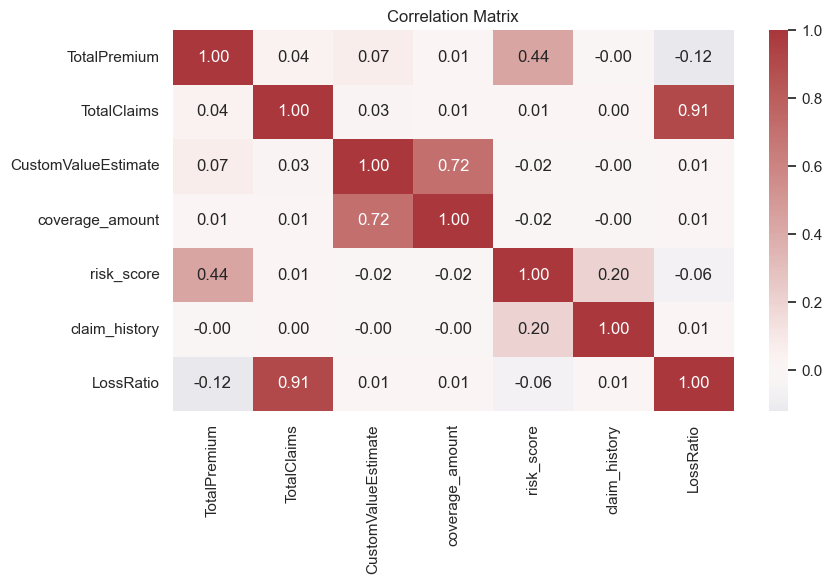

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["TotalPremium", "TotalClaims", "CustomValueEstimate"]):
    sns.histplot(df[col], bins=35, kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")
plt.tight_layout(); plt.show()

zip_summary = df.groupby("ZipCode", as_index=False).agg(TotalPremium=("TotalPremium", "sum"), TotalClaims=("TotalClaims", "sum"), ClaimFrequency=("TotalClaims", lambda s: (s > 0).mean()))
plt.figure(figsize=(8, 5))
sns.scatterplot(data=zip_summary, x="TotalPremium", y="TotalClaims", size="ClaimFrequency", sizes=(20, 180), alpha=0.45)
plt.title("TotalPremium vs TotalClaims by ZipCode")
plt.tight_layout(); plt.show()

corr_cols = ["TotalPremium", "TotalClaims", "CustomValueEstimate", "coverage_amount", "risk_score", "claim_history", "LossRatio"]
plt.figure(figsize=(9, 6))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap="vlag", center=0, fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout(); plt.show()

## Geographic Trends

Province-level comparisons of cover type, premium, and vehicle make are shown below.

,Province,Policies,AvgPremium,AvgClaims,LossRatio
2,Gauteng,2547,2083.687393,1939.154554,1.049782
3,KwaZulu-Natal,1617,1986.282338,1678.993426,0.937828
5,Mpumalanga,664,1911.878840,1517.614714,0.925606
0,Eastern Cape,1017,1802.892104,1584.815841,0.961339
8,Western Cape,1738,1724.763602,1621.731479,1.108564
6,North West,584,1720.117671,1491.360890,1.004425
1,Free State,668,1619.965778,1763.678698,1.270680
4,Limpopo,788,1545.915292,1401.352728,1.004893
7,Northern Cape,377,1524.767294,1349.571167,0.968038


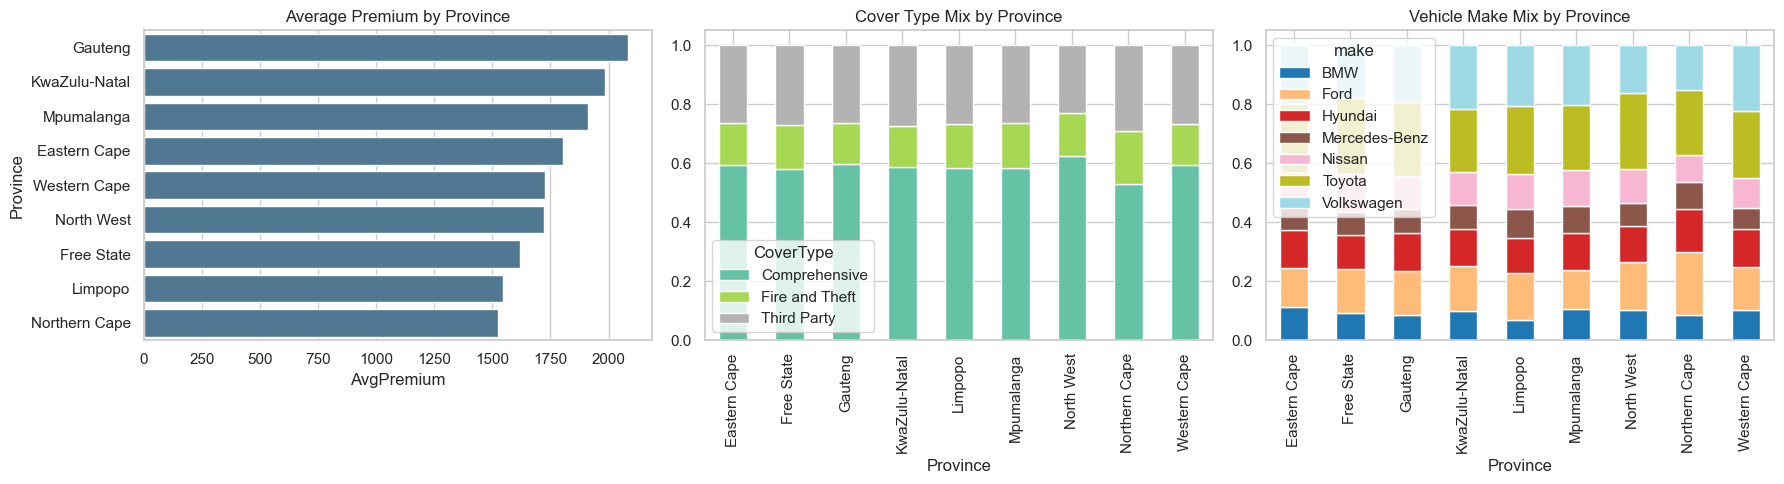

In [4]:
province_summary = df.groupby("Province", as_index=False).agg(Policies=("PolicyID", "count"), AvgPremium=("TotalPremium", "mean"), AvgClaims=("TotalClaims", "mean"), LossRatio=("LossRatio", "mean")).sort_values("AvgPremium", ascending=False)
display(province_summary)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.barplot(data=province_summary, y="Province", x="AvgPremium", ax=axes[0], color="#457B9D")
axes[0].set_title("Average Premium by Province")
pd.crosstab(df["Province"], df["CoverType"], normalize="index").plot(kind="bar", stacked=True, ax=axes[1], colormap="Set2")
axes[1].set_title("Cover Type Mix by Province")
pd.crosstab(df["Province"], df["make"], normalize="index").plot(kind="bar", stacked=True, ax=axes[2], colormap="tab20")
axes[2].set_title("Vehicle Make Mix by Province")
plt.tight_layout(); plt.show()

## Outlier Detection

Box plots are applied to `TotalClaims`, `CustomValueEstimate`, and `TotalPremium`.

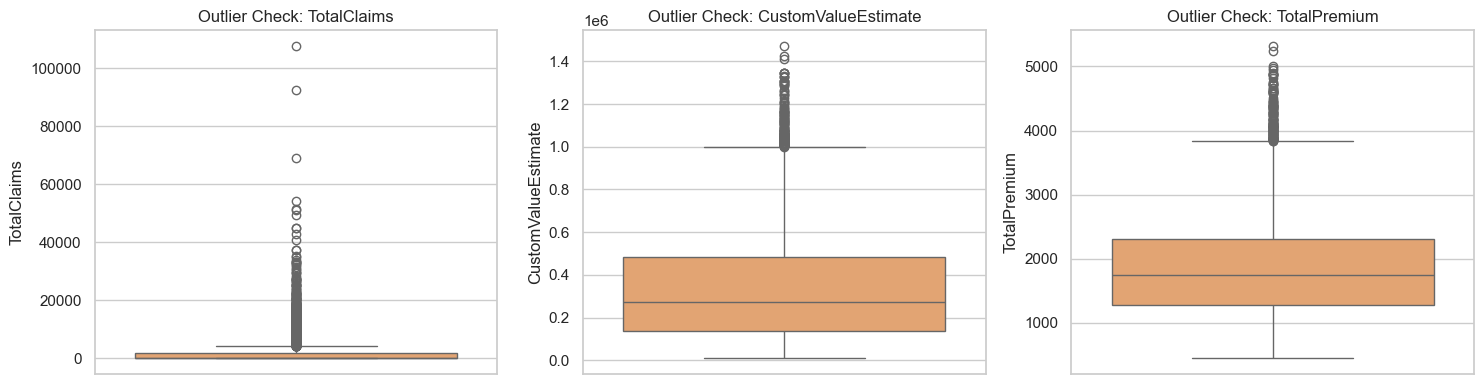

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["TotalClaims", "CustomValueEstimate", "TotalPremium"]):
    sns.boxplot(y=df[col], ax=ax, color="#F4A261")
    ax.set_title(f"Outlier Check: {col}")
plt.tight_layout(); plt.show()

## Guiding Questions

The notebook answers: Loss Ratio by Province/VehicleType/Gender, temporal trends in claim frequency/severity, and vehicle make/model risk profiles.

In [6]:
for group_col in ["Province", "VehicleType", "Gender"]:
    print(f"Loss Ratio by {group_col}")
    display(df.groupby(group_col, as_index=False).agg(Policies=("PolicyID", "count"), TotalPremium=("TotalPremium", "sum"), TotalClaims=("TotalClaims", "sum"), LossRatio=("LossRatio", "mean")).sort_values("LossRatio", ascending=False))
monthly = df.assign(Period=df["TransactionMonth"].dt.to_period("M").dt.to_timestamp()).groupby("Period", as_index=False).agg(ClaimFrequency=("TotalClaims", lambda s: (s > 0).mean()), ClaimSeverity=("TotalClaims", lambda s: s[s > 0].mean()))
display(monthly.tail(12))
vehicle_risk = df.groupby(["make", "Model"], as_index=False).agg(Policies=("PolicyID", "count"), TotalPremium=("TotalPremium", "sum"), TotalClaims=("TotalClaims", "sum"), LossRatio=("LossRatio", "mean")).sort_values("LossRatio", ascending=False)
display(vehicle_risk.head(10))

Loss Ratio by Province


,Province,Policies,TotalPremium,TotalClaims,LossRatio
1,Free State,668,1082137.14,1178137.37,1.270680
8,Western Cape,1738,2997639.14,2818569.31,1.108564
2,Gauteng,2547,5307151.79,4939026.65,1.049782
4,Limpopo,788,1218181.25,1104265.95,1.004893
6,North West,584,1004548.72,870954.76,1.004425
7,Northern Cape,377,574837.27,508788.33,0.968038
0,Eastern Cape,1017,1833541.27,1611757.71,0.961339
3,KwaZulu-Natal,1617,3211818.54,2714932.37,0.937828
5,Mpumalanga,664,1269487.55,1007696.17,0.925606


Loss Ratio by VehicleType


,VehicleType,Policies,TotalPremium,TotalClaims,LossRatio
1,Hatchback,2178,3483984.38,3367691.72,1.114859
2,SUV,2424,5046220.58,4638755.64,1.068663
0,Bakkie,1644,3260938.51,3031839.56,1.036826
3,Sedan,3355,5777690.77,4940677.21,0.953665
4,Truck,399,930508.43,775164.49,0.949237


Loss Ratio by Gender


,Gender,Policies,TotalPremium,TotalClaims,LossRatio
1,Male,4931,9130342.01,8643796.98,1.073669
0,Female,4773,8828361.61,7655659.20,0.992363
2,Not specified,296,540639.05,454672.44,0.914274


,Period,ClaimFrequency,ClaimSeverity
12,2024-01-01,0.420925,5318.308208
13,2024-02-01,0.460000,4211.298370
14,2024-03-01,0.382212,3569.291006
15,2024-04-01,0.384248,4038.697702
16,2024-05-01,0.389163,4330.483228
17,2024-06-01,0.439141,3519.495598
18,2024-07-01,0.391408,3954.977622
19,2024-08-01,0.414392,3766.672994
20,2024-09-01,0.358911,4151.109172
21,2024-10-01,0.411085,4621.992303


,make,Model,Policies,TotalPremium,TotalClaims,LossRatio
1,BMW,X3,317,761726.58,907875.64,1.426347
8,Hyundai,i20,416,650185.46,689451.55,1.191477
20,Volkswagen,Tiguan,656,1195734.90,1229258.11,1.182933
17,Toyota,Hilux,775,1291569.67,1324720.11,1.147986
4,Ford,Fiesta,504,930604.53,883892.20,1.146850
10,Mercedes-Benz,GLA,286,679899.64,640517.45,1.123796
15,Toyota,Corolla,794,1319514.17,1315718.61,1.105837
0,BMW,320i,316,757666.85,722679.05,1.081599
7,Hyundai,Tucson,443,730187.19,689124.06,1.071916
5,Ford,Ranger,484,891414.77,778835.10,1.034728


## Insight Visualizations

Three decision-focused views: province loss-ratio ranking, temporal claim dynamics, and high-risk make/model profiles.

C:\Users\Administrator\AppData\Local\Temp\ipykernel_4552\520265979.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=province_loss, y="Province", x="LossRatio", ax=axes[0], palette="rocket")


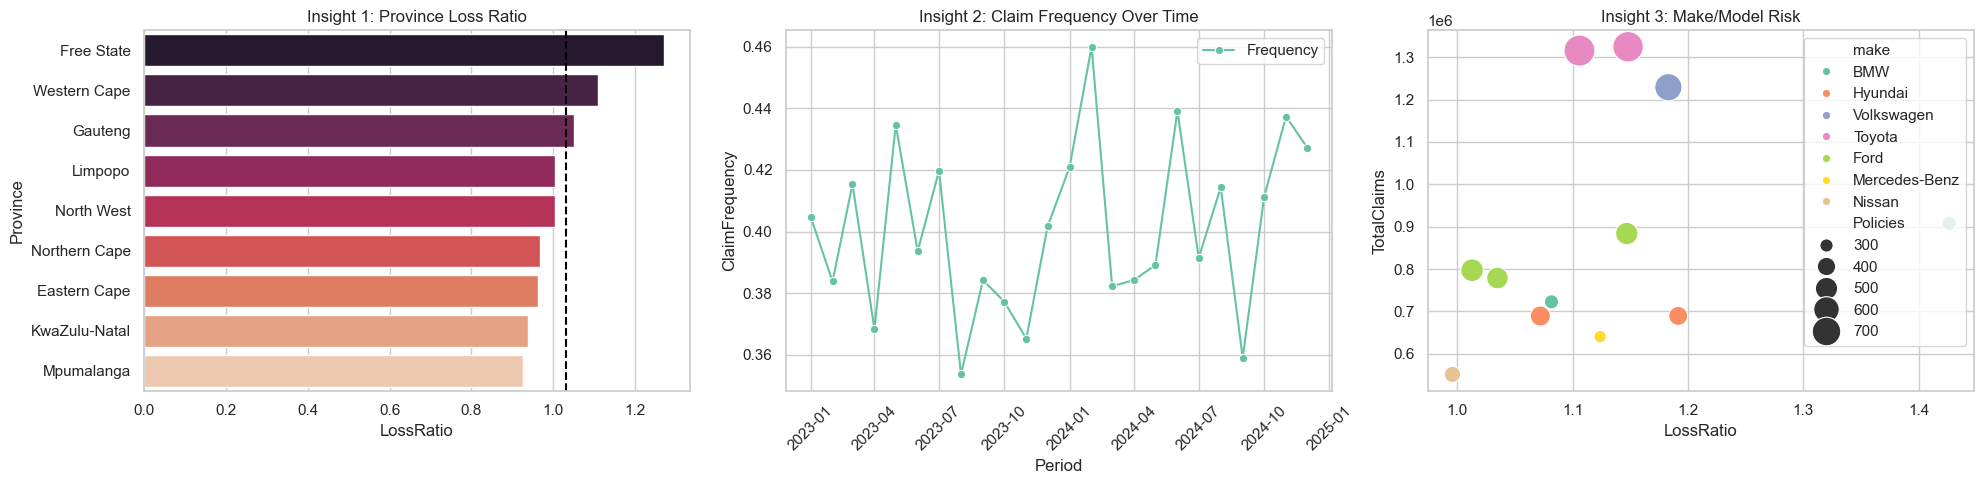

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
province_loss = df.groupby("Province", as_index=False).agg(LossRatio=("LossRatio", "mean")).sort_values("LossRatio", ascending=False)
sns.barplot(data=province_loss, y="Province", x="LossRatio", ax=axes[0], palette="rocket")
axes[0].axvline(df["LossRatio"].mean(), color="black", linestyle="--")
axes[0].set_title("Insight 1: Province Loss Ratio")
sns.lineplot(data=monthly, x="Period", y="ClaimFrequency", marker="o", ax=axes[1], label="Frequency")
axes[1].tick_params(axis="x", rotation=45)
axes[1].set_title("Insight 2: Claim Frequency Over Time")
top_models = vehicle_risk.head(12)
sns.scatterplot(data=top_models, x="LossRatio", y="TotalClaims", size="Policies", hue="make", sizes=(80, 500), ax=axes[2])
axes[2].set_title("Insight 3: Make/Model Risk")
plt.tight_layout(); plt.show()